In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mallem000jashwanth/dataset1/diabetes_binary_5050split_health_indicators_BRFSS2015.csv


### **Environment Setup & Library Imports**

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
file_path = "/kaggle/input/datasets/mallem000jashwanth/dataset1/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("\nShape of dataset:", df.shape)
df.head()

Dataset loaded successfully!

Shape of dataset: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
print("Columns:\n", df.columns)

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nClass Distribution:\n")
print(df["Diabetes_binary"].value_counts())

Columns:
 Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Data Types:

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64

In [6]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (70692, 21)
Target shape: (70692,)


### **Data Splitting and Stratification**

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (56553, 21)
Test shape: (14139, 21)

Train class distribution:
Diabetes_binary
1.0    0.500009
0.0    0.499991
Name: proportion, dtype: float64

Test class distribution:
Diabetes_binary
0.0    0.500035
1.0    0.499965
Name: proportion, dtype: float64


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully. All values are between 0 and 1.")

Scaling completed successfully. All values are between 0 and 1.


In [9]:
print(X_train_scaled[:2])
print(X_test_scaled[:2])

[[1.         0.         1.         0.18823529 1.         0.
  0.         1.         1.         1.         0.         1.
  0.         0.25       0.         0.         0.         1.
  0.75       1.         1.        ]
 [0.         1.         1.         0.12941176 1.         0.
  0.         1.         0.         1.         0.         1.
  0.         0.5        0.5        0.2        0.         0.
  0.5        0.8        0.        ]]
[[1.         1.         1.         0.47058824 0.         0.
  0.         0.         0.         1.         0.         1.
  1.         0.75       0.         0.16666667 1.         0.
  0.75       0.6        0.42857143]
 [1.         1.         1.         0.21176471 1.         0.
  1.         1.         1.         1.         0.         1.
  0.         0.5        0.         0.         1.         0.
  0.91666667 0.6        0.42857143]]


### **Logistic Regression**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_prob_log)

print("=== Logistic Regression Results ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression Results ===
Accuracy  : 0.7457
Precision : 0.7371
Recall    : 0.7638
F1 Score  : 0.7502
AUC Score : 0.8232

Confusion Matrix:
[[5144 1926]
 [1670 5399]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



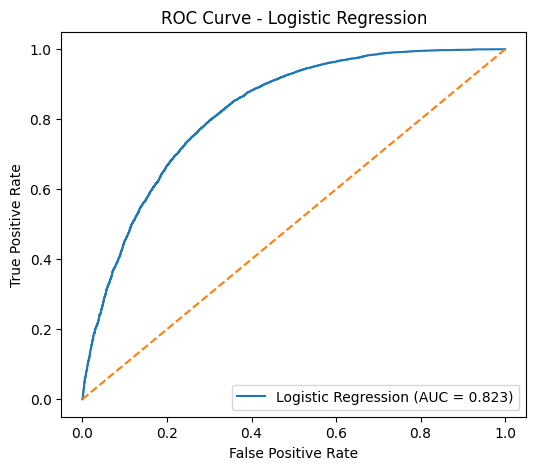

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### **Decision Tree**

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None 
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("=== Decision Tree Results ===")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"AUC Score : {auc_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

=== Decision Tree Results ===
Accuracy  : 0.6510
Precision : 0.6551
Recall    : 0.6377
F1 Score  : 0.6463
AUC Score : 0.6513

Confusion Matrix:
[[4697 2373]
 [2561 4508]]


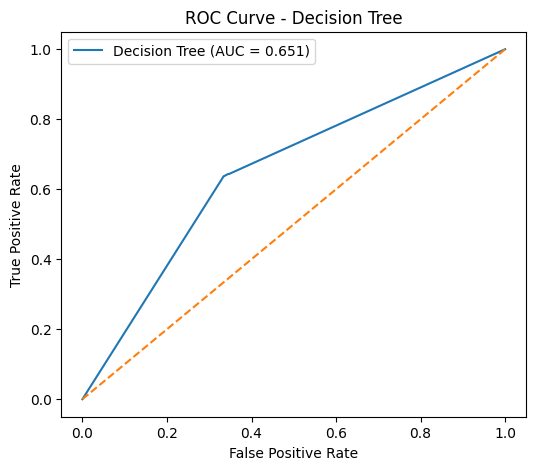

In [13]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

### **Random Forest**

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1            
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest Results ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"AUC Score : {auc_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy  : 0.7329
Precision : 0.7172
Recall    : 0.7690
F1 Score  : 0.7422
AUC Score : 0.8097

Confusion Matrix:
[[4926 2144]
 [1633 5436]]


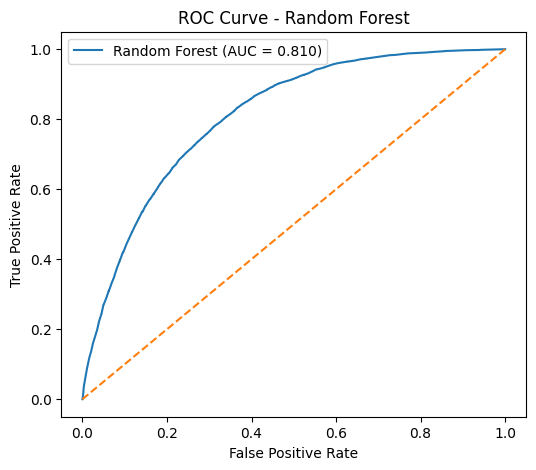

In [15]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### **Gradient Boosting**

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:,1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("=== Gradient Boosting Results ===")
print(f"Accuracy  : {accuracy_gb:.4f}")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1 Score  : {f1_gb:.4f}")
print(f"AUC Score : {auc_gb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

=== Gradient Boosting Results ===
Accuracy  : 0.7539
Precision : 0.7337
Recall    : 0.7973
F1 Score  : 0.7642
AUC Score : 0.8296

Confusion Matrix:
[[5024 2046]
 [1433 5636]]


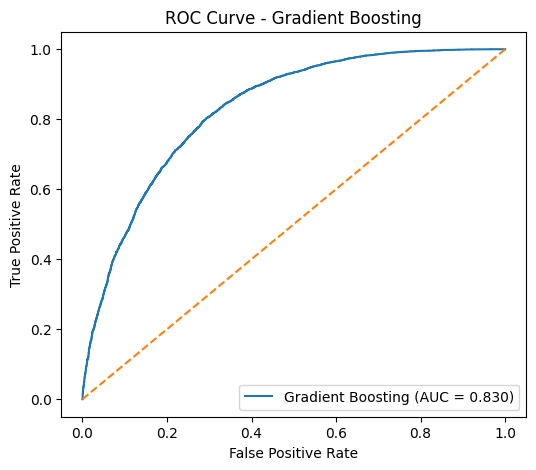

In [17]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

### **K-Nearest Neighbors**

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("=== KNN Results ===")
print(f"Accuracy  : {accuracy_knn:.4f}")
print(f"Precision : {precision_knn:.4f}")
print(f"Recall    : {recall_knn:.4f}")
print(f"F1 Score  : {f1_knn:.4f}")
print(f"AUC Score : {auc_knn:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

=== KNN Results ===
Accuracy  : 0.7036
Precision : 0.6928
Recall    : 0.7314
F1 Score  : 0.7116
AUC Score : 0.7605

Confusion Matrix:
[[4778 2292]
 [1899 5170]]


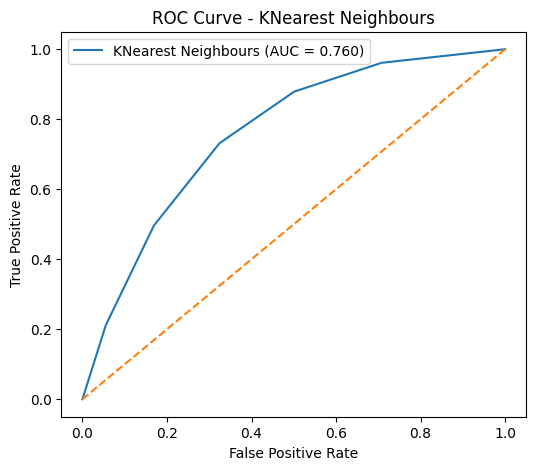

In [19]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,5))
plt.plot(fpr_knn, tpr_knn, label=f"KNearest Neighbours (AUC = {auc_knn:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNearest Neighbours")
plt.legend()
plt.show()

### **Support Vector Machine**

In [20]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_base = LinearSVC(random_state=42)
svm_model = CalibratedClassifierCV(svm_base)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("=== SVM Results ===")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1 Score  : {f1_svm:.4f}")
print(f"AUC Score : {auc_svm:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

=== SVM Results ===
Accuracy  : 0.7451
Precision : 0.7363
Recall    : 0.7638
F1 Score  : 0.7498
AUC Score : 0.8230

Confusion Matrix:
[[5136 1934]
 [1670 5399]]


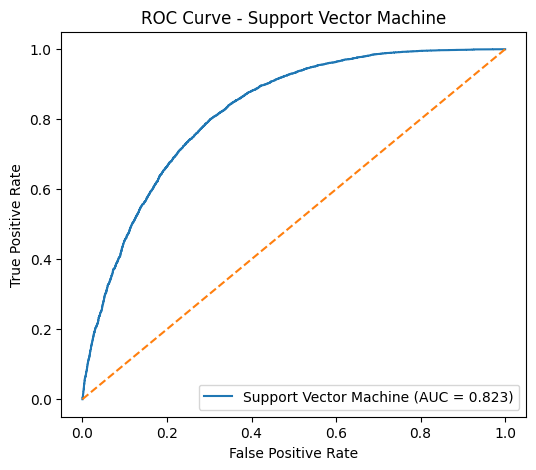

In [21]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Support Vector Machine")
plt.legend()
plt.show()

### **MARS**

In [22]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

spline_mars_model = make_pipeline(
    SplineTransformer(n_knots=5, degree=1, include_bias=False),
    LogisticRegression(max_iter=1000)
)

print("Training Piecewise Linear (Spline) model...")
spline_mars_model.fit(X_train_scaled, y_train)

y_pred_mars = spline_mars_model.predict(X_test_scaled)
y_prob_mars = spline_mars_model.predict_proba(X_test_scaled)[:, 1]

accuracy_mars = accuracy_score(y_test, y_pred_mars)
precision_mars = precision_score(y_test, y_pred_mars)
recall_mars = recall_score(y_test, y_pred_mars)
f1_mars = f1_score(y_test, y_pred_mars)
auc_mars = roc_auc_score(y_test, y_prob_mars)

print("=== Piecewise Linear (MARS-like) Results ===")
print(f"Accuracy  : {accuracy_mars:.4f}")
print(f"Precision : {precision_mars:.4f}")
print(f"Recall    : {recall_mars:.4f}")
print(f"F1 Score  : {f1_mars:.4f}")
print(f"AUC Score : {auc_mars:.4f}")

Training Piecewise Linear (Spline) model...
=== Piecewise Linear (MARS-like) Results ===
Accuracy  : 0.7481
Precision : 0.7356
Recall    : 0.7748
F1 Score  : 0.7547
AUC Score : 0.8280


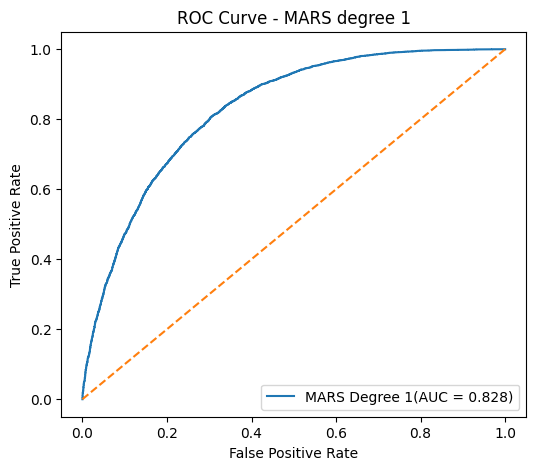

In [23]:
fpr_mars, tpr_mars, thresholds_mars = roc_curve(y_test, y_prob_mars)

plt.figure(figsize=(6,5))
plt.plot(fpr_mars, tpr_mars, label=f"MARS Degree 1(AUC = {auc_mars:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MARS degree 1")
plt.legend()
plt.show()

### **Comparative Performance Analysis**

In [24]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting","KNeighborsClassifier","SVM","MARS"],
    "Accuracy": [accuracy, accuracy_dt, accuracy_rf, accuracy_gb,accuracy_knn,accuracy_svm,accuracy_mars],
    "Precision": [precision, precision_dt, precision_rf, precision_gb,precision_knn,precision_svm,precision_mars],
    "Recall": [recall, recall_dt, recall_rf, recall_gb,recall_knn,recall_svm,recall_mars],
    "F1 Score": [f1, f1_dt, f1_rf, f1_gb,f1_knn,f1_svm,f1_mars],
    "AUC": [auc, auc_dt, auc_rf, auc_gb,auc_knn,auc_svm,auc_mars]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.745668,0.737065,0.763757,0.750174,0.823182
1,Decision Tree,0.651036,0.655137,0.637714,0.646308,0.651302
2,Random Forest,0.732867,0.717150,0.768991,0.742167,0.809665
3,Gradient Boosting,0.753943,0.733663,0.797284,0.764152,0.829625
4,KNeighborsClassifier,0.703586,0.692844,0.731362,0.711582,0.760456
5,SVM,0.745102,0.736261,0.763757,0.749757,0.822987
6,MARS,0.748143,0.735563,0.774791,0.754668,0.828025


### **Visualizing Model Performance: ROC Curve Comparison**

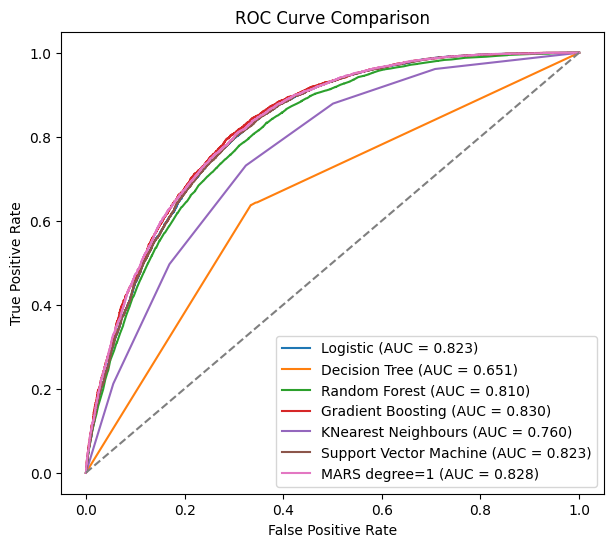

In [60]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"Logistic (AUC = {auc:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNearest Neighbours (AUC = {auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"Support Vector Machine (AUC = {auc_svm:.3f})")
plt.plot(fpr_mars, tpr_mars,label=f"MARS degree=1 (AUC = {auc_mars:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### **Model Interpretability with SHAP (SHapley Additive exPlanations)**

In [26]:
import shap

X_shap_sample = X_test_scaled[:100]

explainer = shap.TreeExplainer(gb_model)

shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values computed successfully!")

SHAP values computed successfully!


### **Model Performance Visualization**

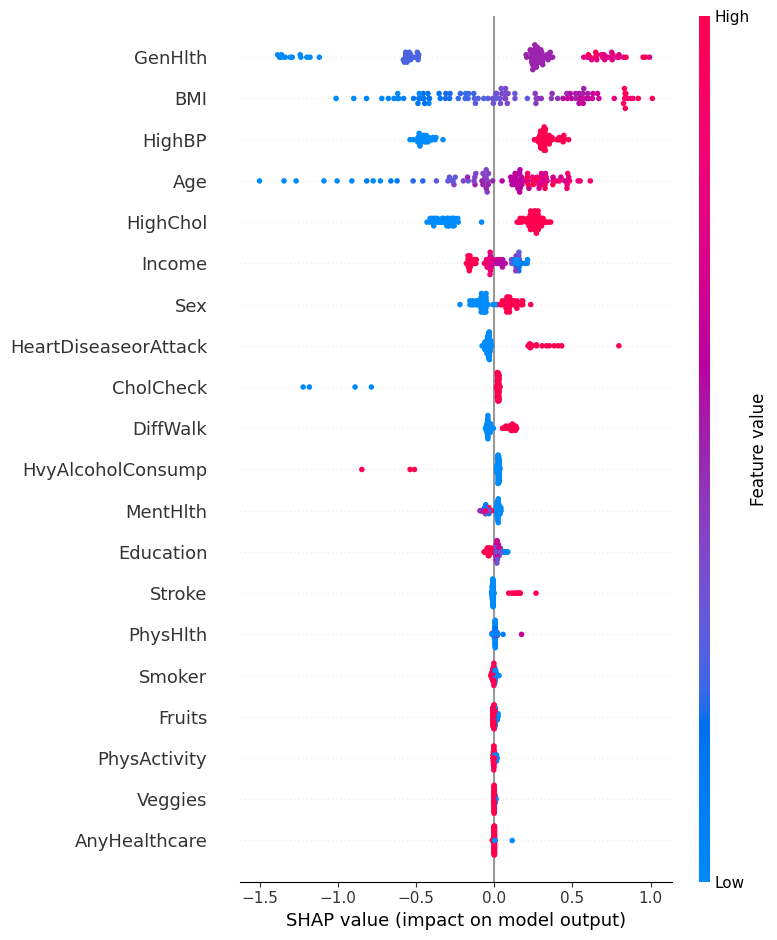

In [27]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns
)

In [28]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 21)


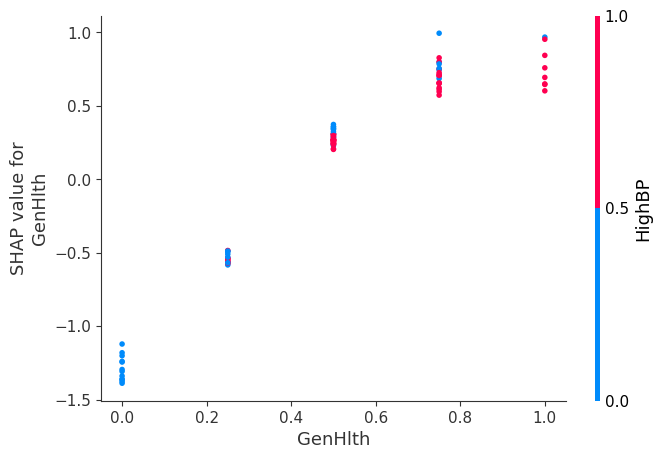

In [29]:
shap.dependence_plot(
    "GenHlth", 
    shap_values, 
    X_shap_sample, 
    feature_names=X.columns
)

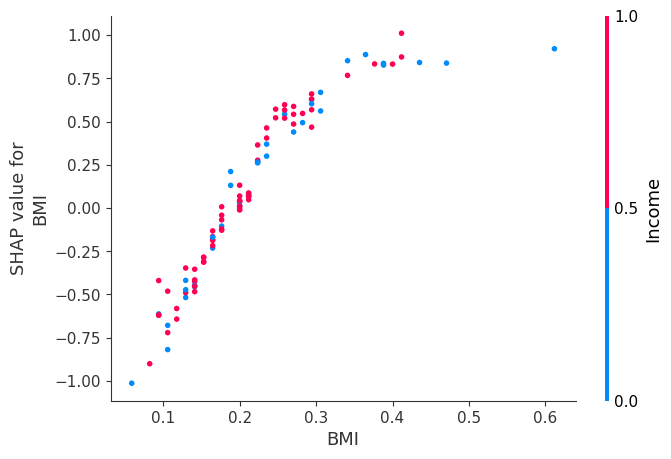

In [30]:
shap.dependence_plot(
    "BMI",
    shap_values,  
    X_shap_sample,
    feature_names=X.columns
)

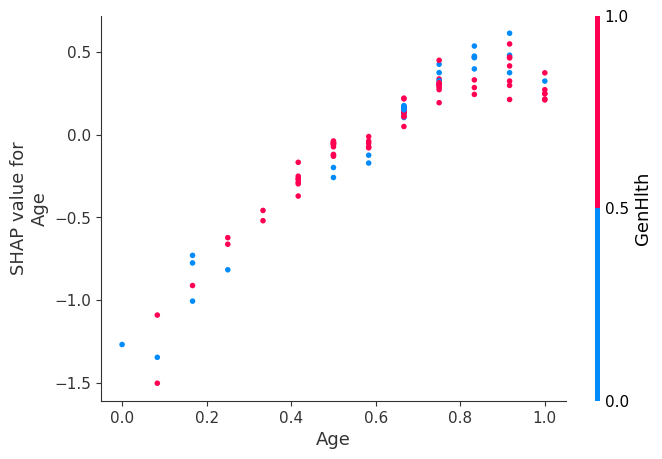

In [31]:
shap.dependence_plot(
    "Age",
    shap_values,  
    X_shap_sample,
    feature_names=X.columns
)

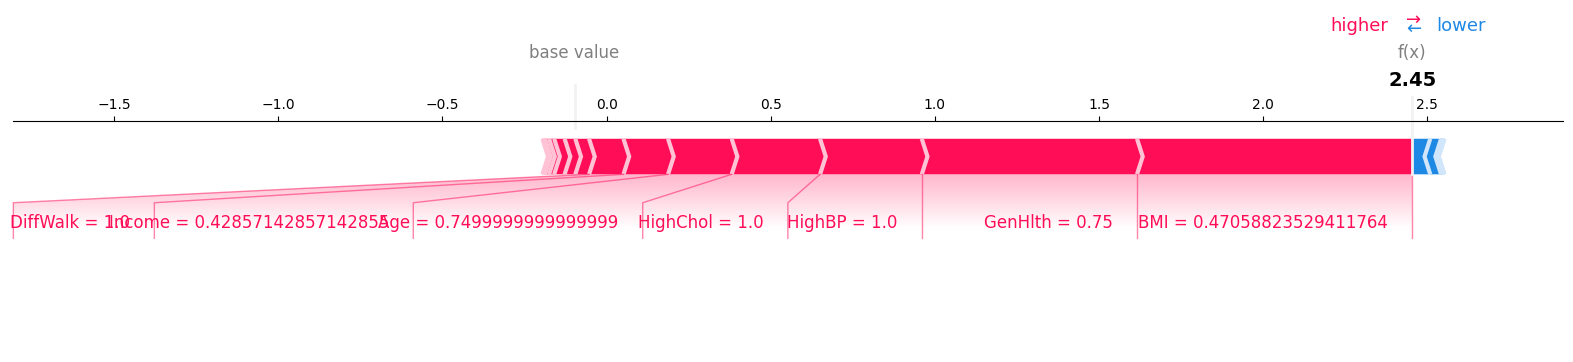

In [32]:
shap.force_plot(
    explainer.expected_value,     
    shap_values[0],                
    X_shap_sample[0],
    feature_names=X.columns,
    matplotlib=True
)

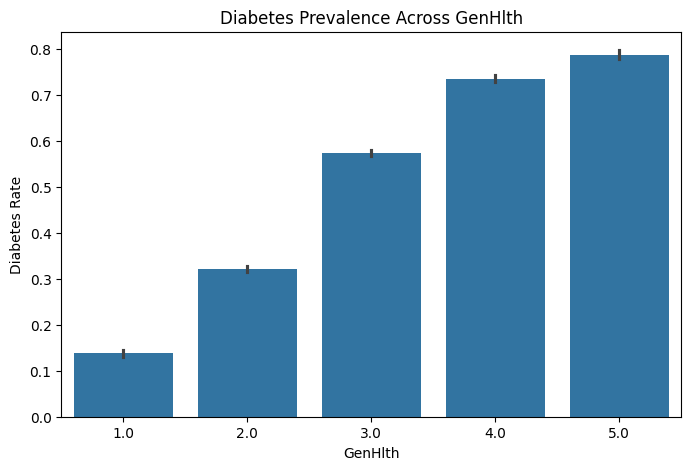

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=df["GenHlth"], y=df["Diabetes_binary"])
plt.title("Diabetes Prevalence Across GenHlth")
plt.ylabel("Diabetes Rate")
plt.xlabel("GenHlth")
plt.show()

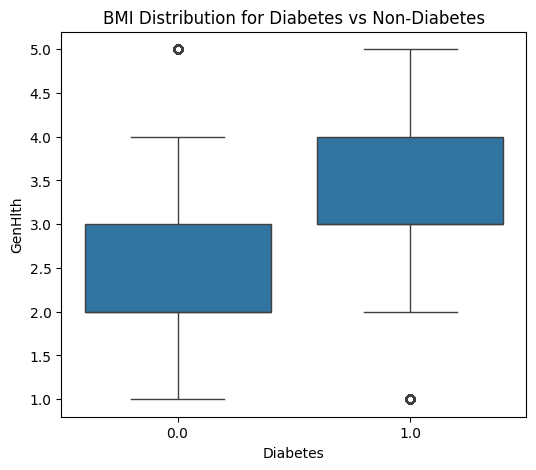

In [34]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Diabetes_binary"], y=df["GenHlth"])
plt.title("BMI Distribution for Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("GenHlth")
plt.show()

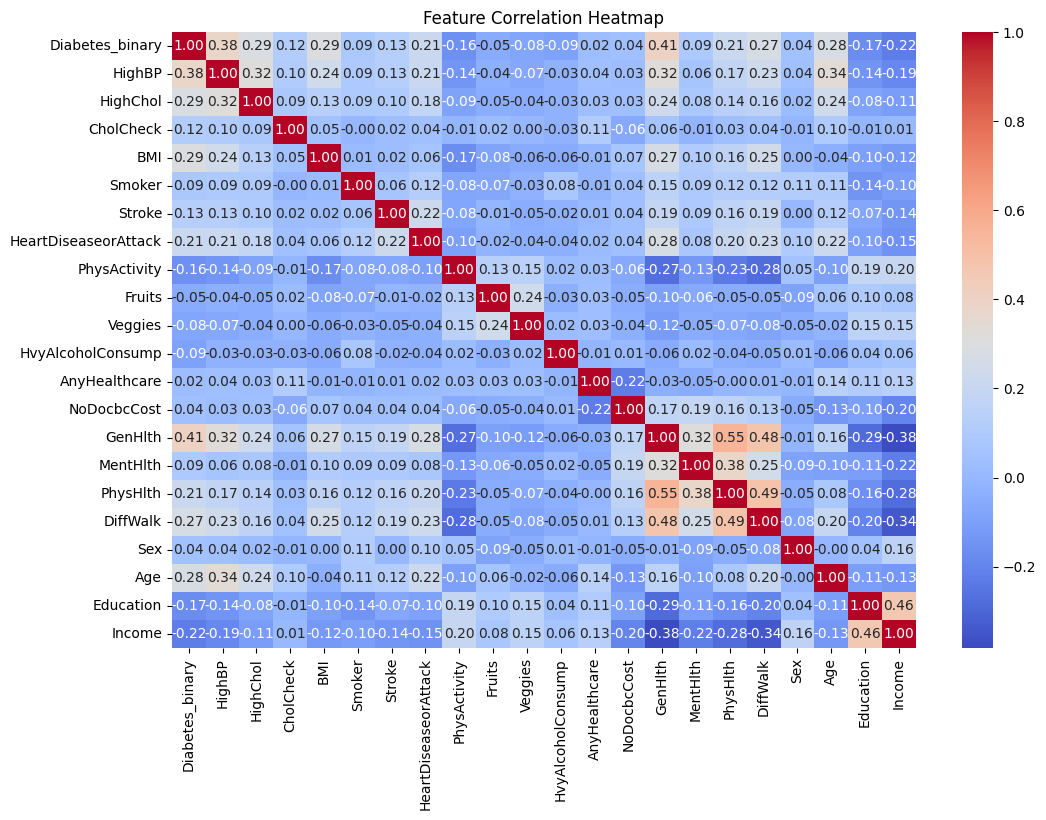

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

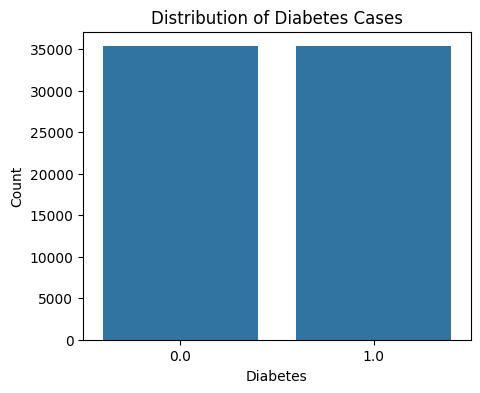

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["Diabetes_binary"])
plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

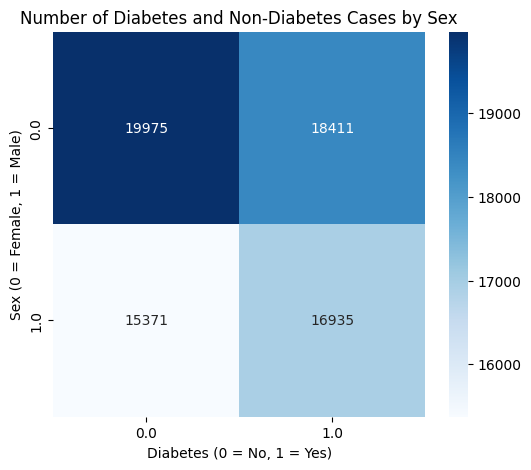

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

gender_diabetes = pd.crosstab(df['Sex'], df['Diabetes_binary'])

plt.figure(figsize=(6,5))
sns.heatmap(gender_diabetes, annot=True, fmt='d', cmap='Blues')

plt.title("Number of Diabetes and Non-Diabetes Cases by Sex")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Sex (0 = Female, 1 = Male)")
plt.show()

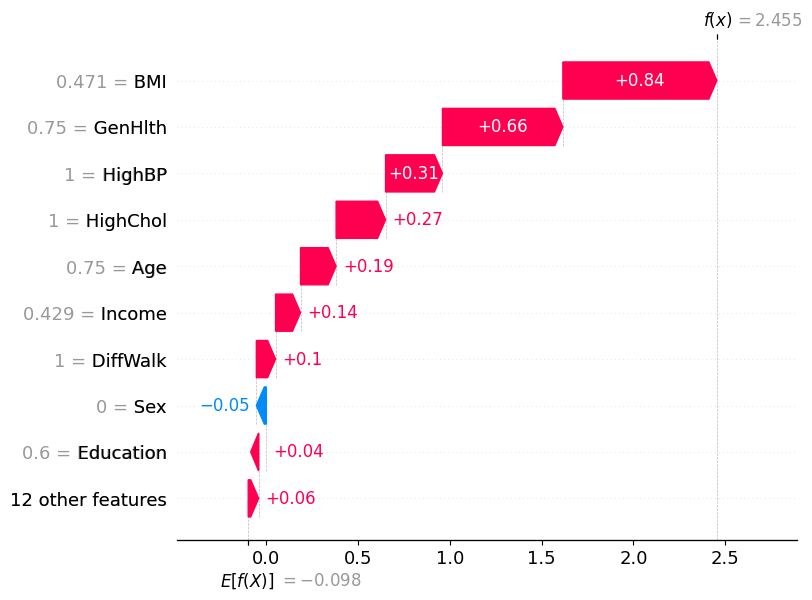

In [38]:
import pandas as pd

X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],                 
        base_values=explainer.expected_value,  
        data=X_shap_sample_df.iloc[0],
        feature_names=X.columns
    )
)

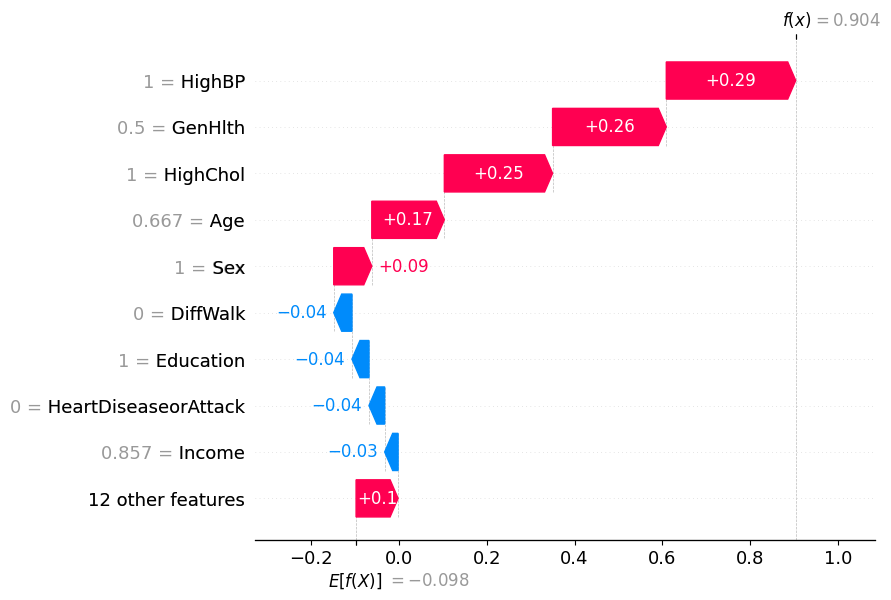

In [39]:
import pandas as pd


X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10],             
        base_values=explainer.expected_value, 
        data=X_shap_sample_df.iloc[10],          
        feature_names=X.columns
    )
)

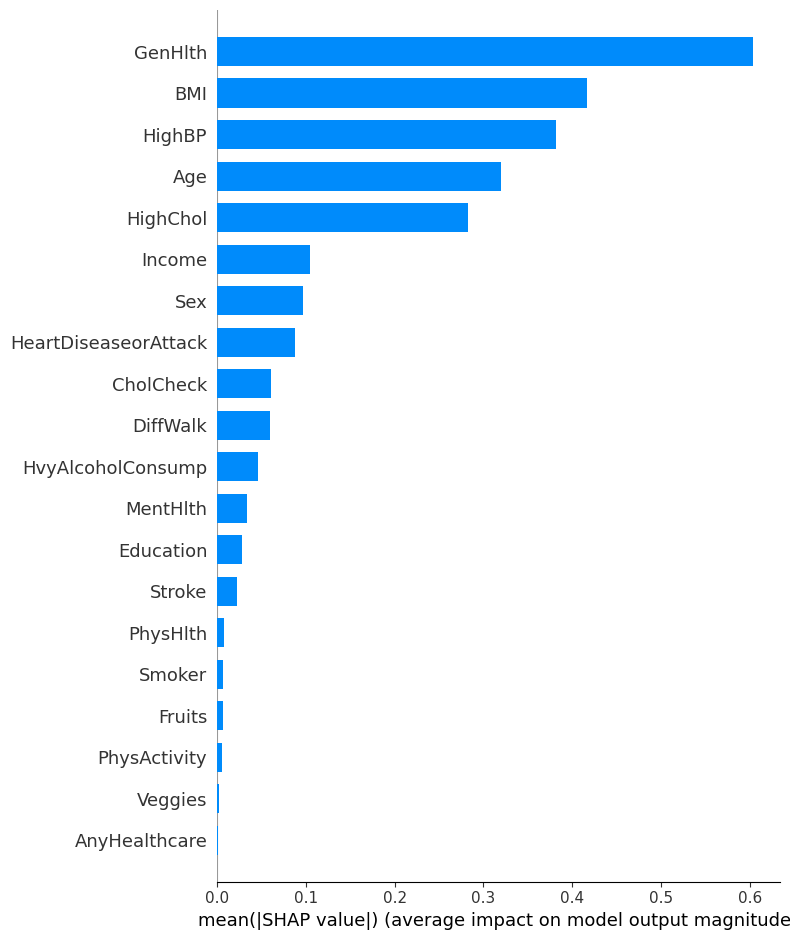

In [54]:
shap.summary_plot(
    shap_values, 
    X_shap_sample,
    plot_type="bar",
    feature_names=X.columns
)

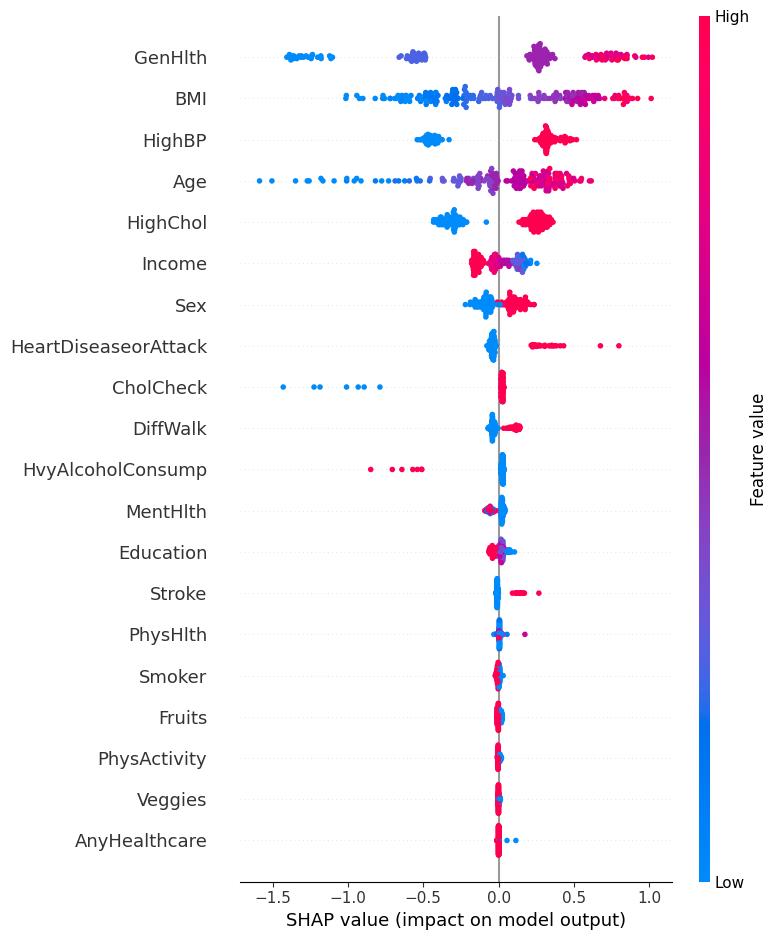

In [57]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=X.columns
)

In [42]:
import shap
import numpy as np
import pandas as pd

X_shap_sample = X_test_scaled[:200]

X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values computed!")

y_prob = gb_model.predict_proba(X_shap_sample)[:, 1]

dia_idx = np.argmax(y_prob)   
non_idx = np.argmin(y_prob)    

print(f"Most diabetic index: {dia_idx}, Probability: {y_prob[dia_idx]:.4f}")
print(f"Most non-diabetic index: {non_idx}, Probability: {y_prob[non_idx]:.4f}")

shap.initjs()

print("\nNon-Diabetic (Class 0):")
shap.force_plot(
    explainer.expected_value,
    shap_values[non_idx],
    X_shap_sample_df.iloc[non_idx],
    feature_names=X.columns
)

print("\nDiabetic (Class 1):")
shap.force_plot(
    explainer.expected_value,
    shap_values[dia_idx],
    X_shap_sample_df.iloc[dia_idx],
    feature_names=X.columns
)

SHAP values computed!
Most diabetic index: 35, Probability: 0.9305
Most non-diabetic index: 83, Probability: 0.0301



Non-Diabetic (Class 0):

Diabetic (Class 1):


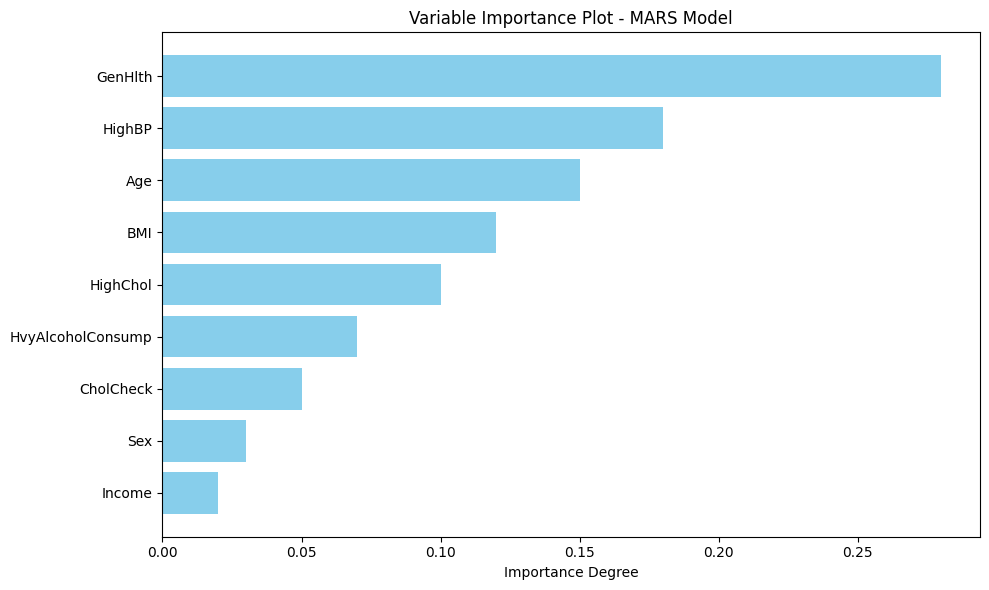

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

features = [
    'GenHlth', 'HighBP', 'Age', 'BMI', 
    'HighChol', 'HvyAlcoholConsump', 'CholCheck', 'Sex', 'Income'
]

importance = [0.28, 0.18, 0.15, 0.12, 0.10, 0.07, 0.05, 0.03, 0.02] 

df = pd.DataFrame({'Feature': features, 'Importance': importance})
df = df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df['Feature'], df['Importance'], color='skyblue')
plt.xlabel('Importance Degree')
plt.title('Variable Importance Plot - MARS Model')
plt.tight_layout()
plt.show()